# Bank Marketing Campaign
---------------------------

Scenario: Products- Credit Cards / Loans / Term Deposits.

Bank Conducted a Telemarketing Campaign in which Existing Bank Customers were
Contacted and were pitched the Banking Products.
eg. `Term Deposit`

Objective: You are Provided with Data of Telemarketing Campaign , As an Analyst you are asked to Analyze / Explore Dataset and Extract Patterns / Inferences from the Data to find Potential Customers also to Reduce Cost on future Telemarketing Campaigns.



Dataset URL :

https://drive.google.com/file/d/1rsYRSm5SD0w4-Cb1H0XRwYvdzh9iUaHX/view?usp=sharing

# Import Libraries
-----

In [ ]:
# for Processing

import numpy as np
import pandas as pd

# for data visualization

from matplotlib import pyplot as plt
import seaborn as sns

# fix warnings

import warnings
warnings.filterwarnings('ignore')

# Loading Dataset
----------------

In [ ]:
inp0   = pd.read_csv('v1.csv', skiprows=2)

In [ ]:
inp0.head(3)

,customerid,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,1,58.0,100000,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no
1,2,44.0,60000,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no
2,3,33.0,120000,2,married,"entrepreneur,secondary",yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no


# MetaData Inspection
-----

In [ ]:
# Find the ROW & COL COUNT

inp0.shape

(45211, 19)

In [ ]:
# Find the Column Names

print( inp0.columns.tolist())

['customerid', 'age', 'salary', 'balance', 'marital', 'jobedu', 'targeted', 'default', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'response']


In [ ]:
# Find the DataType of Each Column

inp0.dtypes

,0
customerid,int64
age,float64
salary,int64
balance,int64
marital,object
jobedu,object
targeted,object
default,object
housing,object
loan,object


In [ ]:
# Find the statistical Facts about Numerical Columns.

inp0.describe()

,customerid,age,salary,balance,day,campaign,pdays,previous
count,45211.000000,45191.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,22606.000000,40.935651,57006.171065,1362.272058,15.806419,2.763841,40.197828,0.580323
std,13051.435847,10.619198,32085.718415,3044.765829,8.322476,3.098021,100.128746,2.303441
min,1.000000,18.000000,0.000000,-8019.000000,1.000000,1.000000,-1.000000,0.000000
25%,11303.500000,33.000000,20000.000000,72.000000,8.000000,1.000000,-1.000000,0.000000
50%,22606.000000,39.000000,60000.000000,448.000000,16.000000,2.000000,-1.000000,0.000000
75%,33908.500000,48.000000,70000.000000,1428.000000,21.000000,3.000000,-1.000000,0.000000
max,45211.000000,95.000000,120000.000000,102127.000000,31.000000,63.000000,871.000000,275.000000


# Answer Below Questions
-------------------------------
- For How Many Customers Age Data is Available    __________
- What is the Avg Age of Customer                 __________
- What is the Age Range of Most of the Customers  __________
- What is the Age of Youngest Customer            __________
- what %age of Customers are younger then 33 Years ?  ______
- What is the Age of Oldest Customer              __________


<pre>
For How Many Customers Age Data is Available - 45191
What is the Avg Age of Customer - 40.935651
What is the Age Range of Most of the Customers 30.3 to 51.55
What is the Age of Youngest Customer - 18
what %age of Customers are younger then 33 Years ? 25%
What is the Age of Oldest Customer - 95

# DataType Inspection & Correction ( Data Cleaning )
----

# What is the datatype of Age Column?
-----

In [ ]:
inp0.age.dtype

dtype('float64')

# Task : Convert the Age from Float to Integer
-----

In [ ]:
inp0['age'] = inp0.age.astype('Int64')

In [ ]:
inp0['age'] = pd.to_numeric(inp0['age'],errors='coerce')

In [ ]:
inp0.age.dtype

Int64Dtype()

# What is the average age of customer?


In [ ]:
inp0.age.mean()

np.float64(40.93565090394105)

# Is Customerid is of any importance from analytics ? if yes in which case we require customerid column ?
-----

In [ ]:
inp0.customerid.head()

,customerid
0,1
1,2
2,3
3,4
4,5


In [ ]:
# dropping customer id

inp0.drop('customerid',axis=1,inplace=True)

In [ ]:
inp0.head()

,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,58,100000,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no
1,44,60000,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no
2,33,120000,2,married,"entrepreneur,secondary",yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no
3,47,20000,1506,married,"blue-collar,unknown",no,no,yes,no,unknown,5,"may, 2017",92 sec,1,-1,0,unknown,no
4,33,0,1,single,"unknown,unknown",no,no,no,no,unknown,5,"may, 2017",198 sec,1,-1,0,unknown,no


# Feature Engineering ( Populating New Columns using Existing Column)
-----

In [ ]:
inp0.jobedu.head()

,jobedu
0,"management,tertiary"
1,"technician,secondary"
2,"entrepreneur,secondary"
3,"blue-collar,unknown"
4,"unknown,unknown"


In [ ]:
# Let us populate a new column say 'job'

In [ ]:
'management,tertiary'.split(',')[0]

'management'

In [ ]:
inp0['job'] =  inp0.jobedu.apply( lambda    row :     row.split(',')[0] )

In [ ]:
inp0.job.head()

,job
0,management
1,technician
2,entrepreneur
3,blue-collar
4,unknown


In [ ]:
inp0['edu'] = inp0.jobedu.apply( lambda    row :     row.split(',')[1] )

In [ ]:
# verify
inp0[['job','edu']].head()

,job,edu
0,management,tertiary
1,technician,secondary
2,entrepreneur,secondary
3,blue-collar,unknown
4,unknown,unknown


# Missing Value Inspection
----------------------------------------------

Find the Count of Missing values in each Column Sorted by Count in Descending order!



In [ ]:
inp0.isna().sum().sort_values(ascending=False)

,0
month,50
response,30
age,20
salary,0
marital,0
balance,0
default,0
jobedu,0
housing,0
loan,0


# To Decide if column is needed to be removed or Imputed , you are asked to find the missing % in entire dataframe for 'month','response' and 'age' column.
---------------

In [ ]:
# month
inp0['month'].isna().sum() / len(inp0) * 100

np.float64(0.11059255490920351)

In [ ]:
# response
inp0['response'].isna().sum() / len(inp0) * 100

np.float64(0.0663555329455221)

In [ ]:
# age
inp0['age'].isna().sum() / len(inp0) * 100

np.float64(0.0442370219636814)

# Let us Focus on Age Missing %age i.e. 0.04
---------------------------------------------------

What makes more sense to you ?

1. Replace (impute) the missing values in age column with say mean.
2. Delete the 0.04% of Rows .

In [ ]:
inp1 = inp0[  ~ inp0.age.isnull() ]

In [ ]:
inp1.age.isna().sum()

np.int64(0)

# Let us Focus on Month Missing %age i.e. .11%
---------------------------------------------------

What makes more sense to you ?

1. Replace (impute) the missing values in month column with say mean/median/mode.
2. Delete the 0.11% of Rows .


In [ ]:
inp1.month.head()

,month
0,"may, 2017"
1,"may, 2017"
2,"may, 2017"
3,"may, 2017"
4,"may, 2017"


In [ ]:
inp1.month.mode()

,month
0,"may, 2017"


In [ ]:
inp1.month.mode()[0]

'may, 2017'

#.fillna(): this function is used to replace NaN in a given column.

In [ ]:
inp1.month.fillna(      inp1.month.mode()[0]             ,      inplace=True)

In [ ]:
inp1.month.isna().sum()

np.int64(0)

In [ ]:
# pdays means after how many days since last campaign the customer was contacted.

inp1.pdays.head()
# -1 indicates absence of value (this is done by developer)

,pdays
0,-1
1,-1
2,-1
3,-1
4,-1


In [ ]:
inp1.pdays.describe()

,pdays
count,45191.000000
mean,40.181253
std,100.074099
min,-1.000000
25%,-1.000000
50%,-1.000000
75%,-1.000000
max,871.000000


# are the above stats Correct ? if no why ?

In [ ]:
# above data is incorrect ! reason
# -1 which indicates missing value affects / COUNT/MAX/MIN and other aggregates.

Solution: impute -1 with NaN

In [ ]:
inp1.loc[ inp1.pdays < 0 , 'pdays'] = np.nan

In [ ]:
# what is the meaning of above expression ?
# find all records where inp1.pdays < 0 i.e. -1
# assign/replace values with np.nan in 'pdays' column.

In [ ]:
inp1.pdays.describe()

,pdays
count,8252.000000
mean,224.523752
std,115.202715
min,1.000000
25%,133.000000
50%,194.500000
75%,327.000000
max,871.000000


# Analysis
----------------------

Univariate Analysis


Let us Observe the Age Distribution using Histogram.
----

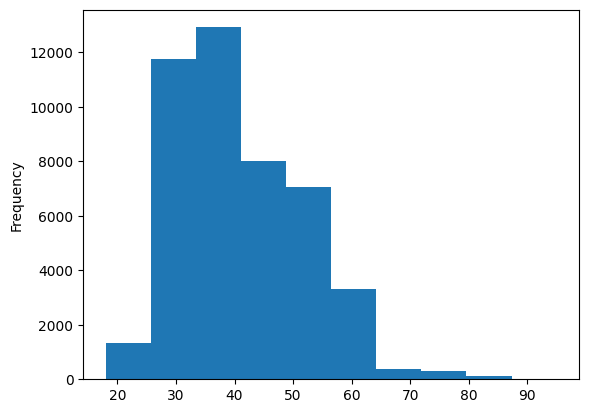

In [ ]:
inp1.age.plot.hist()
plt.show()

# Whisker Plot or Box Plot
---------------------------------
we use to plot to observe/anaylyse **distribution** of Data.

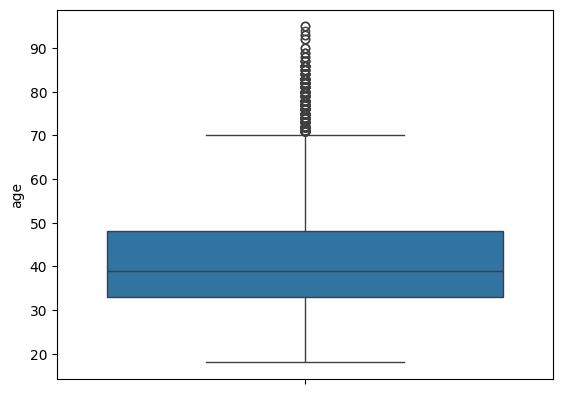

In [ ]:
sns.boxplot( inp1.age);

Half of the Customers are Younger then ___ ?

In [ ]:
inp1.age.median()

np.float64(39.0)

# Activity ⁉
---------------------

Analyse the Salary Distribution using BoxPlot / Histogram

In [ ]:
inp1.salary.head()

,salary
0,100000
1,60000
2,120000
3,20000
4,0


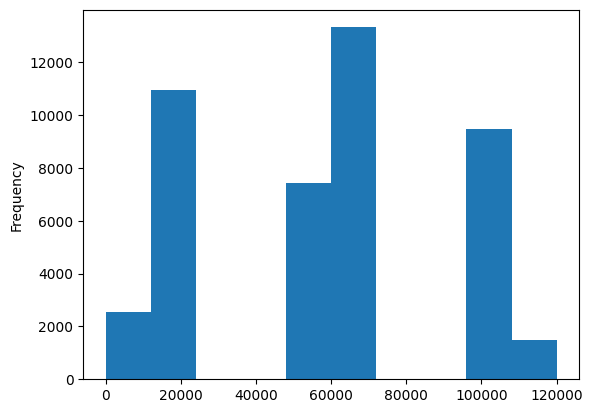

In [ ]:
inp1.salary.plot.hist();

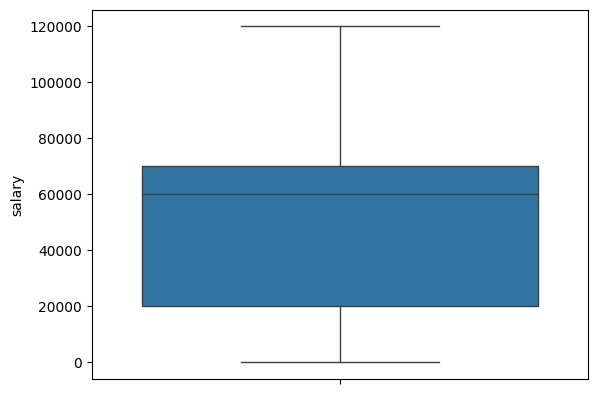

In [ ]:
sns.boxplot(inp1.salary);

In [ ]:
inp1.salary.describe()

,salary
count,45191.000000
mean,57005.974641
std,32084.253154
min,0.000000
25%,20000.000000
50%,60000.000000
75%,70000.000000
max,120000.000000


# Analyse the Balance Distribution
------

In [ ]:
inp1.balance.head()

,balance
0,2143
1,29
2,2
3,1506
4,1


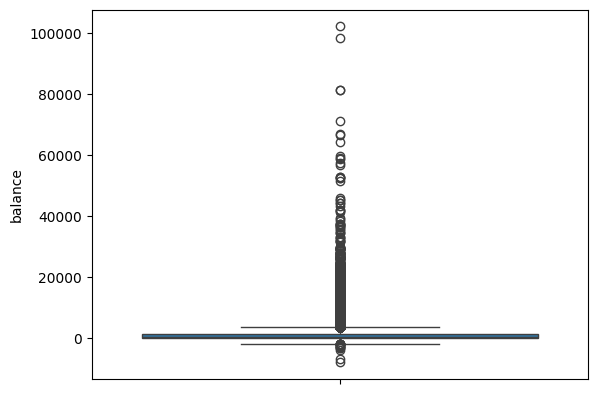

In [ ]:

sns.boxplot(inp1.balance);

In [ ]:
inp1.balance.describe()

,balance
count,45191.000000
mean,1362.432520
std,3045.120417
min,-8019.000000
25%,72.000000
50%,448.000000
75%,1428.000000
max,102127.000000


# Data Standardization
-----------------------------

In [ ]:
inp1.duration.head()

,duration
0,261 sec
1,151 sec
2,76 sec
3,92 sec
4,198 sec


In [ ]:
inp1.duration.unique()

array(['261 sec', '151 sec', '76 sec', ..., '20.7666666666667 min',
       '25.9333333333333 min', '16.2833333333333 min'], dtype=object)

In [ ]:
# Convert all Seconds  into Minutes.

In [ ]:
# if 'sec' in Element
#       split element by space
#       fetch[0] index value
#       convert to float
#       divide by 60

In [ ]:
inp1.duration = inp1.duration.apply( lambda x : float(x.split()[0])/60  if 'sec' in x else float(x.split()[0])  )

In [ ]:
inp1.duration.unique().tolist()

[4.35,
 2.5166666666666666,
 1.2666666666666666,
 1.5333333333333334,
 3.3,
 2.316666666666667,
 3.6166666666666667,
 6.333333333333333,
 0.8333333333333334,
 0.9166666666666666,
 3.7,
 2.283333333333333,
 8.616666666666667,
 1.1833333333333333,
 2.9,
 5.883333333333334,
 1.6333333333333333,
 0.6333333333333333,
 3.65,
 0.9,
 4.366666666666666,
 2.7333333333333334,
 2.6666666666666665,
 5.7,
 3.0166666666666666,
 2.8666666666666667,
 4.933333333333334,
 2.1166666666666667,
 4.25,
 5.8,
 3.75,
 3.8333333333333335,
 3.466666666666667,
 3.7666666666666666,
 5.6,
 4.033333333333333,
 6.083333333333333,
 27.766666666666666,
 9.616666666666667,
 3.0,
 0.36666666666666664,
 24.866666666666667,
 10.266666666666667,
 5.916666666666667,
 6.05,
 4.433333333333334,
 4.216666666666667,
 2.9833333333333334,
 13.116666666666667,
 2.4166666666666665,
 1.7333333333333334,
 0.21666666666666667,
 3.0833333333333335,
 29.633333333333333,
 2.3,
 13.533333333333333,
 6.516666666666667,
 5.95,
 1.51666666666

# Analysis
----

In [ ]:
# find the Customers Distribution by their Marital Status

<Axes: ylabel='marital'>

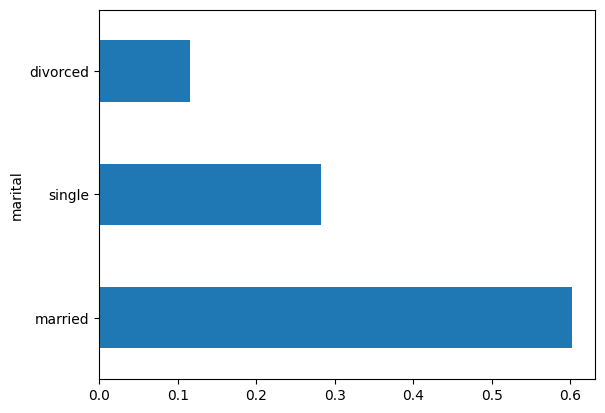

In [ ]:
inp1.marital.value_counts(normalize=True).plot.barh()

# Activity
-------------------------
can you try finding the customer distribution by the JOB !

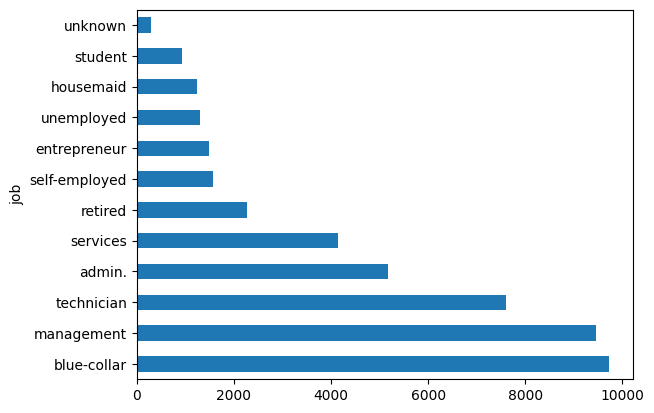

In [ ]:
inp1.job.value_counts().plot(kind='barh');

# Bivariate Analysis
-----

Balance vs Salary
------

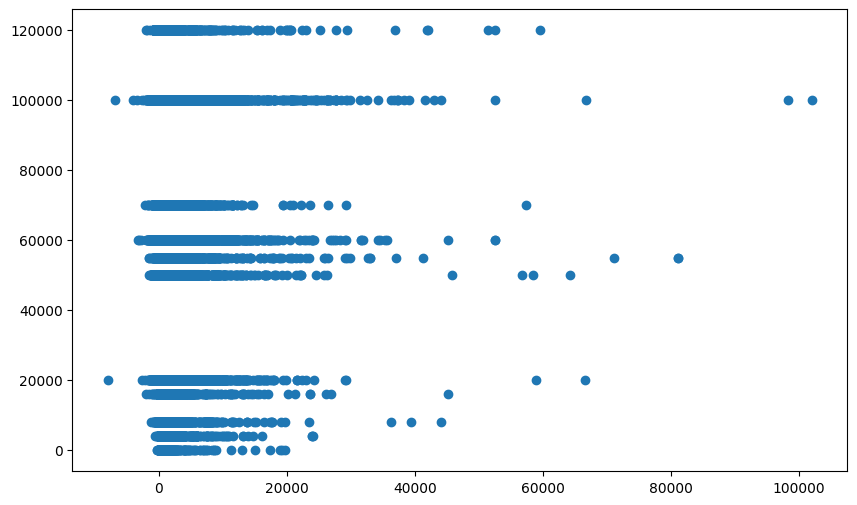

In [ ]:
plt.figure( figsize=(10,6))

plt.scatter( inp1.balance , inp1.salary) # X axis=balance , Y Axis=Salary

plt.show()

# Another Example
-----------------------------

what does the Age vs Balance Tells you in Scatter Plot ?

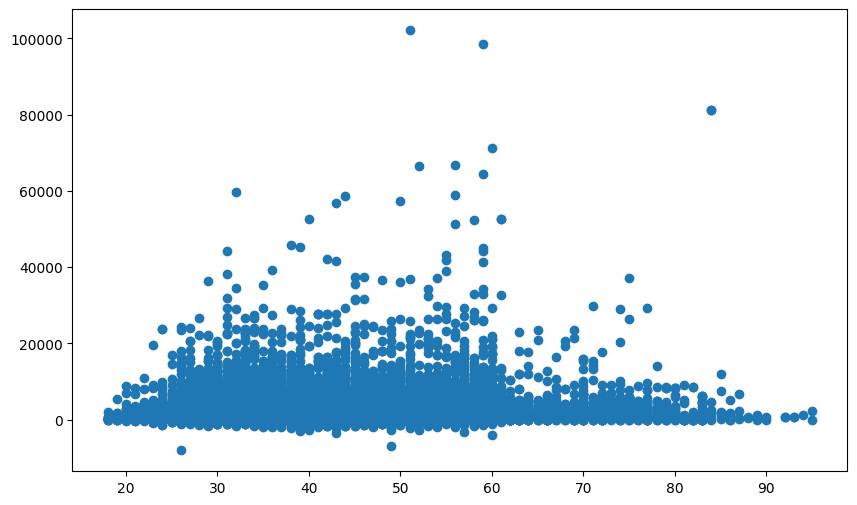

In [ ]:
plt.figure( figsize=(10,6))

plt.scatter( inp1.age , inp1.balance) # X axis=age , Y Axis=balance

plt.show()


# Education & Salary (Mean & Median)

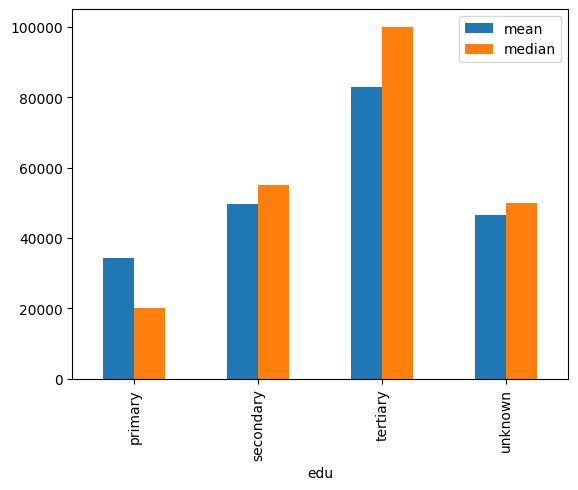

In [ ]:
inp1.groupby('edu')['salary'].aggregate(['mean','median']).plot.bar();

# END